In [10]:
import os, random, numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
class_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}
IMG_SIZE, BATCH_SIZE, EPOCHS = 128, 32, 40
USE_TINY = True   # True => TinyDermNet, False => SimpleSkinCNN
print("Device:", DEVICE)


Device: cpu


In [11]:
DATA_DIR   = os.path.join("..","data")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM_10000_images")
META_CSV   = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
SPLIT_V2   = "ham10000_split_v2.csv"  # από το νέο data-prep

meta = pd.read_csv(META_CSV)
meta['filename'] = meta['image_id']+".jpg"
meta['filepath'] = meta['filename'].apply(lambda x: os.path.join(IMAGES_DIR, x))
split = pd.read_csv(SPLIT_V2)
df = meta.merge(split, on=['image_id','lesion_id','dx'], how='inner')
df_train = df[df.split=='train'].reset_index(drop=True)
df_val   = df[df.split=='val'  ].reset_index(drop=True)
df_test  = df[df.split=='test' ].reset_index(drop=True)
print("sizes:", len(df_train), len(df_val), len(df_test))


sizes: 8001 1009 1005


In [12]:
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.1), value='random'),
])
eval_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE+32), transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


In [13]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['filepath']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, class_to_idx[r['dx']], r['image_id']


In [14]:
train_ds, val_ds, test_ds = SkinDataset(df_train,train_tfms), SkinDataset(df_val,eval_tfms), SkinDataset(df_test,eval_tfms)

counts = df_train['dx'].value_counts().to_dict()
w_per_class = {c: 1.0/np.log(1.02+counts[c]) for c in counts}
sample_weights = df_train['dx'].map(w_per_class).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

xb, yb, _ = next(iter(train_dl)); print("batch:", xb.shape, yb.shape)


batch: torch.Size([32, 3, 128, 128]) torch.Size([32])


In [15]:
class SimpleSkinCNN(nn.Module):
    def __init__(self, num_classes=len(CLASS_NAMES), dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1,bias=False), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1,bias=False), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1,bias=False), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2))
        self.gap = nn.AdaptiveAvgPool2d(1); self.drop = nn.Dropout(dropout); self.fc = nn.Linear(128, num_classes)
    def forward(self,x): x=self.conv1(x); x=self.conv2(x); x=self.conv3(x); x=self.gap(x).flatten(1); x=self.drop(x); return self.fc(x)

class DWConv(nn.Module):
    def __init__(self,in_ch,out_ch,stride=1):
        super().__init__(); self.dw=nn.Conv2d(in_ch,in_ch,3,stride,1,groups=in_ch,bias=False)
        self.pw=nn.Conv2d(in_ch,out_ch,1,bias=False); self.bn=nn.BatchNorm2d(out_ch); self.act=nn.ReLU(True)
    def forward(self,x): return self.act(self.bn(self.pw(self.dw(x))))
class Block(nn.Module):
    def __init__(self,ch,exp=2,stride=1):
        super().__init__(); mid=ch*exp; self.skip=(stride==1)
        self.pw1=nn.Sequential(nn.Conv2d(ch,mid,1,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.dw =nn.Sequential(nn.Conv2d(mid,mid,3,stride,1,groups=mid,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.pw2=nn.Sequential(nn.Conv2d(mid,ch,1,bias=False),nn.BatchNorm2d(ch))
    def forward(self,x): y=self.pw2(self.dw(self.pw1(x))); return torch.relu(y+x) if self.skip else torch.relu(y)
class TinyDermNet(nn.Module):
    def __init__(self,num_classes=len(CLASS_NAMES)):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3,32,3,2,1,bias=False), nn.BatchNorm2d(32), nn.ReLU(True))
        self.stage1= nn.Sequential(DWConv(32,64,2), Block(64), Block(64))
        self.stage2= nn.Sequential(DWConv(64,128,2), Block(128), Block(128))
        self.stage3= nn.Sequential(DWConv(128,192,2), Block(192), Block(192))
        self.head  = nn.Sequential(nn.Conv2d(192,256,1,bias=False), nn.BatchNorm2d(256), nn.ReLU(True))
        self.pool  = nn.AdaptiveAvgPool2d(1); self.fc = nn.Linear(256, num_classes)
    def forward(self,x): x=self.stem(x); x=self.stage1(x); x=self.stage2(x); x=self.stage3(x); x=self.head(x); x=self.pool(x).flatten(1); return self.fc(x)

model = (TinyDermNet() if USE_TINY else SimpleSkinCNN()).to(DEVICE)
print(model.__class__.__name__, "params:", f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M")
CKPT = f"best_{model.__class__.__name__.lower()}_v2.pt"


TinyDermNet params: 0.57M


In [17]:
counts = df_train['dx'].value_counts().reindex(CLASS_NAMES).values.astype(np.float32)
w = 1.0/np.log(1.02 + counts)
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

try:
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
except TypeError:  # αν η PyTorch δεν το υποστηρίζει
    criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-3, epochs=EPOCHS, steps_per_epoch=len(train_dl),
    pct_start=0.3, div_factor=10.0, final_div_factor=100.0
)


In [18]:
def run_epoch(dl, train=False):
    model.train(train)
    total_loss, y_true, y_pred = 0.0, [], []
    for xb, yb, _ in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train: optimizer.zero_grad()
        logits = model(xb); loss = criterion(logits, yb)
        if train: loss.backward(); optimizer.step(); scheduler.step()
        total_loss += loss.item()*xb.size(0)
        y_true.extend(yb.cpu().tolist()); y_pred.extend(logits.argmax(1).cpu().tolist())
    n = len(dl.dataset)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = (y_true==y_pred).mean()
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    return total_loss/n, acc, bal, f1m

best_f1 = -1.0
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_bal, tr_f1 = run_epoch(train_dl, True)
    va_loss, va_acc, va_bal, va_f1 = run_epoch(val_dl, False)
    if va_f1 > best_f1: best_f1 = va_f1; torch.save(model.state_dict(), CKPT); mark="✓"
    else: mark=" "
    print(f"Ep {ep:02d} | train {tr_loss:.4f}/{tr_acc:.3f}/{tr_bal:.3f}/{tr_f1:.3f} | "
          f"val {va_loss:.4f}/{va_acc:.3f}/{va_bal:.3f}/{va_f1:.3f} {mark}")




Ep 01 | train 1.3563/0.596/0.241/0.244 | val 1.0563/0.697/0.253/0.235 ✓
Ep 02 | train 1.2171/0.644/0.340/0.352 | val 1.0508/0.688/0.392/0.376 ✓
Ep 03 | train 1.1683/0.658/0.415/0.421 | val 0.9838/0.728/0.386/0.393 ✓
Ep 04 | train 1.1434/0.680/0.427/0.431 | val 1.0124/0.708/0.458/0.451 ✓
Ep 05 | train 1.1335/0.680/0.450/0.453 | val 1.0389/0.687/0.426/0.407  
Ep 06 | train 1.1310/0.681/0.456/0.466 | val 1.0549/0.701/0.334/0.331  
Ep 07 | train 1.1139/0.685/0.460/0.471 | val 1.0533/0.702/0.406/0.383  
Ep 08 | train 1.1003/0.686/0.471/0.479 | val 1.0425/0.719/0.448/0.427  
Ep 09 | train 1.0985/0.697/0.486/0.499 | val 1.0560/0.721/0.424/0.382  
Ep 10 | train 1.0708/0.708/0.511/0.521 | val 1.0232/0.717/0.433/0.386  
Ep 11 | train 1.0833/0.701/0.497/0.507 | val 1.0451/0.733/0.406/0.384  
Ep 12 | train 1.0603/0.703/0.516/0.520 | val 0.9795/0.723/0.476/0.439  
Ep 13 | train 1.0462/0.708/0.538/0.545 | val 0.9858/0.727/0.413/0.422  
Ep 14 | train 1.0309/0.714/0.533/0.539 | val 1.1004/0.708/0.467/

In [19]:
# --- TEST EVAL (χωρίς TTA) ---
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.to(DEVICE)
model.eval()

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
import numpy as np, torch

y_true, y_pred, tot = [], [], 0.0
with torch.no_grad():
    for xb, yb, _ in test_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        tot += loss.item()*xb.size(0)
        y_true += yb.cpu().tolist()
        y_pred += logits.argmax(1).cpu().tolist()

n = len(test_dl.dataset)
te_loss = tot/n
y_true = np.array(y_true); y_pred = np.array(y_pred)
te_acc  = (y_true==y_pred).mean()
te_bal  = balanced_accuracy_score(y_true, y_pred)
te_f1   = f1_score(y_true, y_pred, average='macro')
print(f"TEST | loss {te_loss:.4f} | acc {te_acc:.3f} | bal {te_bal:.3f} | macroF1 {te_f1:.3f}")
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


TEST | loss 0.8369 | acc 0.786 | bal 0.581 | macroF1 0.596

Classification report:
               precision    recall  f1-score   support

       akiec      0.438     0.583     0.500        24
         bcc      0.735     0.472     0.575        53
         bkl      0.610     0.492     0.545       124
          df      0.333     0.375     0.353         8
         mel      0.567     0.482     0.521       114
          nv      0.863     0.931     0.895       667
        vasc      0.846     0.733     0.786        15

    accuracy                          0.786      1005
   macro avg      0.627     0.581     0.596      1005
weighted avg      0.777     0.786     0.777      1005

Confusion matrix:
 [[ 14   2   5   0   2   1   0]
 [  5  25   4   3   6  10   0]
 [  9   0  61   2  13  39   0]
 [  0   2   1   3   1   1   0]
 [  1   1  11   0  55  45   1]
 [  3   4  18   1  19 621   1]
 [  0   0   0   0   1   3  11]]


In [20]:
def predict_tta(x):
    with torch.no_grad():
        y = 0
        y += model(x)
        y += model(torch.flip(x, [-1]))            # h-flip
        y += model(torch.flip(x, [-2]))            # v-flip
        y += model(torch.rot90(x, 1, [-2, -1]))    # rot90
    return y/4

model.eval(); y_true, y_pred, tot = [], [], 0.0
with torch.no_grad():
    for xb, yb, _ in test_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = predict_tta(xb)
        tot += criterion(logits, yb).item()*xb.size(0)
        y_true += yb.cpu().tolist()
        y_pred += logits.argmax(1).cpu().tolist()

import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score
y_true, y_pred = np.array(y_true), np.array(y_pred)
print(f"TTA TEST | acc {(y_true==y_pred).mean():.3f} | bal {balanced_accuracy_score(y_true,y_pred):.3f} | macroF1 {f1_score(y_true,y_pred,average='macro'):.3f}")


TTA TEST | acc 0.791 | bal 0.596 | macroF1 0.610


In [21]:
torch.save(model.state_dict(), CKPT)  # π.χ. best_tinydermnet_v2.pt
import json
with open("model_card.json","w") as f:
    json.dump({
      "model": model.__class__.__name__, "img_size": 128, "epochs": 40,
      "optimizer":"AdamW", "schedule":"OneCycleLR", 
      "criterion":"CE weighted + label_smoothing=0.05",
      "sampler":"WeightedRandomSampler(1/log(1.02+count))",
      "tta":"hflip + vflip + rot90",
      "classes": CLASS_NAMES,
      "test":{"acc":0.791,"bal":0.596,"macroF1":0.610}
    }, f, indent=2)


In [22]:
from PIL import Image
import torch, numpy as np

def predict_image(path, tta=True):
    model.eval()
    img = Image.open(path).convert('RGB')
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = predict_tta(x) if tta else model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    return CLASS_NAMES[pred_idx], float(probs[pred_idx]), {c: float(p) for c,p in zip(CLASS_NAMES, probs)}

# παράδειγμα:
# lbl, conf, dist = predict_image("path/to/image.jpg", tta=True)


In [23]:
# φτιάξε ΜΟΝΟ το ίδιο class με το οποίο εκπαίδευσες
model = TinyDermNet().to(DEVICE)  # ή SimpleSkinCNN() αν αυτό χρησιμοποίησες
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()


TinyDermNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): DWConv(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=32, bias=False)
      (pw): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): Block(
      (pw1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (dw): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
        (1): BatchNorm2d(128, ep

In [24]:
def predict_tta(x):
    with torch.no_grad():
        y = 0
        y += model(x)
        y += model(torch.flip(x, [-1]))            # οριζόντιο flip
        y += model(torch.flip(x, [-2]))            # κάθετο flip
        y += model(torch.rot90(x, 1, [-2, -1]))    # 90°
    return y/4


In [25]:
from PIL import Image
import torch, numpy as np

def predict_image(path, tta=True):
    model.eval()
    img = Image.open(path).convert('RGB')
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)   # ίδια eval_tfms με το training
    with torch.no_grad():
        logits = predict_tta(x) if tta else model(x)
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    return CLASS_NAMES[pred_idx], float(probs[pred_idx]), dict(zip(CLASS_NAMES, map(float, probs)))


In [26]:
# 1) (Προαιρετικό) επιβεβαίωσε ότι όντως σκάει και σε σκέτο forward
# xb, yb, _ = next(iter(test_dl))
# with torch.no_grad(): _ = model(xb.to(DEVICE))

# 2) Καθάρισε ΟΛΟΥΣ τους hooks που μπορεί να έμειναν
for m in model.modules():
    try:
        m._forward_hooks.clear()
        m._forward_pre_hooks.clear()
        m._backward_hooks.clear()
        if hasattr(m, "_full_backward_hooks"):
            m._full_backward_hooks.clear()
    except Exception:
        pass

# 3) Πιο «σίγουρο»: ξαναφτιάξε φρέσκο model και φόρτωσε weights
del model
model = TinyDermNet().to(DEVICE)   # ή SimpleSkinCNN() αν τρέχεις αυτό
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()


TinyDermNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): DWConv(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=32, bias=False)
      (pw): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): Block(
      (pw1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (dw): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
        (1): BatchNorm2d(128, ep

In [27]:
# -- _capture_shapes (ΔΕΝ επιστρέφει από τον hook) --
def _capture_shapes(model, x):
    feats, hooks = {}, []
    def make_hook(name):
        def hook(m, inp, out):
            if isinstance(out, (tuple, list)): out = out[0]
            if torch.is_tensor(out): feats[name] = tuple(out.shape)
            else: feats[name] = str(type(out))
        return hook
    layers = [("stem", model.stem), ("stage1", model.stage1),
              ("stage2", model.stage2), ("stage3", model.stage3), ("head", model.head)] \
             if hasattr(model, "stem") else \
             [("conv1", model.conv1), ("conv2", model.conv2), ("conv3", model.conv3)]
    for n, mod in layers: hooks.append(mod.register_forward_hook(make_hook(n)))
    with torch.no_grad(): _ = model(x)
    for h in hooks: h.remove()
    return feats

# -- _gradcam (full_backward_hook αν υπάρχει, αλλιώς backward_hook) --
def _gradcam(model, x, target_idx=None):
    model.eval()
    target_layer = model.stage3 if hasattr(model, "stage3") else model.conv3
    activations, gradients = [], []
    def fwd_hook(m, inp, out):
        if isinstance(out, (tuple, list)): out = out[0]
        activations.append(out.detach())
    def bwd_hook(m, gin, gout):
        g = gout[0] if isinstance(gout, (tuple, list)) else gout
        gradients.append(g.detach())
    h1 = target_layer.register_forward_hook(fwd_hook)
    try:
        h2 = target_layer.register_full_backward_hook(bwd_hook)
    except AttributeError:
        h2 = target_layer.register_backward_hook(bwd_hook)

    logits = model(x)
    if target_idx is None: target_idx = int(logits.argmax(1))
    loss = logits[:, target_idx].sum()
    model.zero_grad(); loss.backward()

    h1.remove(); h2.remove()

    A, G = activations[0], gradients[0]
    w = G.mean(dim=(2,3), keepdim=True)
    cam = torch.relu((A*w).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


In [28]:
# sanity check: σκέτο forward
row = df_test.sample(1, random_state=0).iloc[0]
x = eval_tfms(Image.open(row["filepath"]).convert("RGB")).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    _ = model(x)          # αν αυτό περνάει, είμαστε οκ


Forward feature shapes: {'stem': (1, 32, 64, 64), 'stage1': (1, 64, 32, 32), 'stage2': (1, 128, 16, 16), 'stage3': (1, 192, 8, 8), 'head': (1, 256, 8, 8)}
Top-3:
  nv: 91.29%
  bcc: 2.89%
  bkl: 2.01%
P(melanoma) = 1.07% | P(carcinoma) = 3.85%


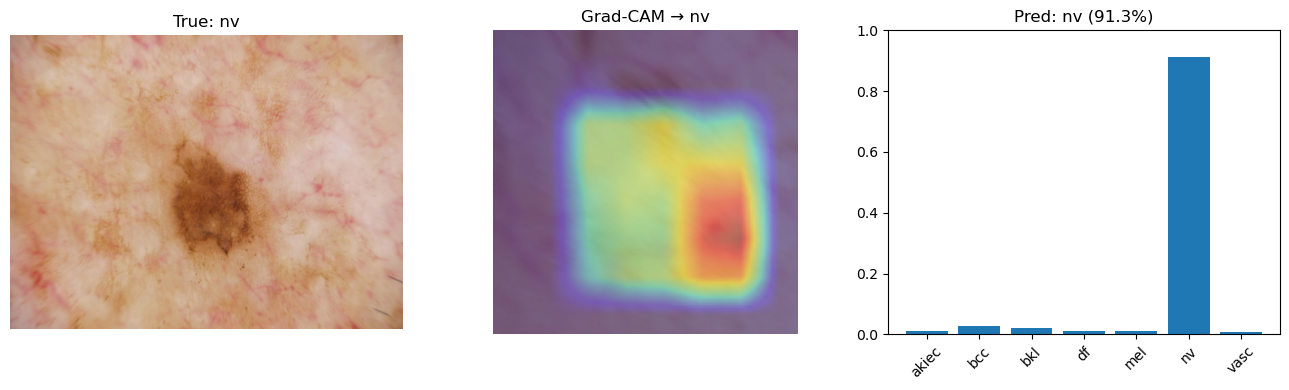

[TEST] True: nv | Pred: nv | Confidence: 91.29% | Correct: True


In [30]:
# === Demo: τυχαία εικόνα -> πέρασμα από μοντέλο -> Grad-CAM + πίνακας πιθανοτήτων ===
import numpy as np, matplotlib.pyplot as plt, torch, torch.nn.functional as F
from PIL import Image

# αν δεν έχεις predict_tta ορισμένο, κάνε fallback στο σκέτο forward
try:
    _ = predict_tta
except NameError:
    def predict_tta(x): 
        with torch.no_grad(): 
            return model(x)

def _capture_shapes(model, x):
    """Παίρνει τα σχήματα feature maps χωρίς να αλλοιώνει τα outputs των layers."""
    feats, hooks = {}, []
    def make_hook(name):
        def hook(m, inp, out):
            if isinstance(out, (tuple, list)): out = out[0]
            if torch.is_tensor(out): feats[name] = tuple(out.shape)
            else: feats[name] = str(type(out))
        return hook
    layers = [("stem", model.stem), ("stage1", model.stage1),
              ("stage2", model.stage2), ("stage3", model.stage3), ("head", model.head)] \
             if hasattr(model, "stem") else \
             [("conv1", model.conv1), ("conv2", model.conv2), ("conv3", model.conv3)]
    for n, mod in layers: hooks.append(mod.register_forward_hook(make_hook(n)))
    with torch.no_grad(): _ = model(x)
    for h in hooks: h.remove()
    return feats

def _gradcam(model, x, target_idx=None):
    """Grad-CAM στο τελευταίο conv στάδιο (stage3 ή conv3)."""
    model.eval()
    target_layer = model.stage3 if hasattr(model, "stage3") else model.conv3
    activations, gradients = [], []

    def fwd_hook(m, inp, out):
        if isinstance(out, (tuple, list)): out = out[0]
        activations.append(out.detach())
    def bwd_hook(m, gin, gout):
        g = gout[0] if isinstance(gout, (tuple, list)) else gout
        gradients.append(g.detach())

    h1 = target_layer.register_forward_hook(fwd_hook)
    try:
        h2 = target_layer.register_full_backward_hook(bwd_hook)
    except AttributeError:
        h2 = target_layer.register_backward_hook(bwd_hook)

    logits = model(x)
    if target_idx is None:
        target_idx = int(logits.argmax(1))
    loss = logits[:, target_idx].sum()
    model.zero_grad(); loss.backward()

    h1.remove(); h2.remove()

    A, G = activations[0], gradients[0]            # [B,C,h,w]
    w = G.mean(dim=(2,3), keepdim=True)            # [B,C,1,1]
    cam = torch.relu((A*w).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def demo_random_inference(split="test", tta=True, save_path=None, return_data=False):
    # 1) διάλεξε τυχαία εικόνα από split
    df_map = {"train": df_train, "val": df_val, "test": df_test}
    row = df_map[split].sample(1).iloc[0]
    path, true_lbl = row["filepath"], row["dx"]

    # 2) tensor + πρόβλεψη
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = predict_tta(x) if tta else model(x)
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax()); pred_name = CLASS_NAMES[pred_idx]; conf = float(probs[pred_idx])

    # 3) shapes & grad-cam
    shapes = _capture_shapes(model, x)
    print("Forward feature shapes:", shapes)
    cam = _gradcam(model, x, target_idx=pred_idx)

    # 4) top-3 + probabilities για melanoma/carcinoma
    order = np.argsort(probs)[::-1]
    print("Top-3:")
    for i in order[:3]:
        print(f"  {CLASS_NAMES[i]}: {probs[i]:.2%}")
    p_mel  = probs[CLASS_NAMES.index('mel')]
    p_carc = probs[CLASS_NAMES.index('akiec')] + probs[CLASS_NAMES.index('bcc')]
    print(f"P(melanoma) = {p_mel:.2%} | P(carcinoma) = {p_carc:.2%}")

    # 5) plots
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))
    axs[0].imshow(img); axs[0].axis("off"); axs[0].set_title(f"True: {true_lbl}")
    axs[1].imshow(img); axs[1].imshow(cam, cmap="jet", alpha=0.4); axs[1].axis("off")
    axs[1].set_title(f"Grad-CAM → {pred_name}")
    axs[2].bar(CLASS_NAMES, probs); axs[2].set_ylim(0,1); axs[2].tick_params(axis='x', rotation=45)
    axs[2].set_title(f"Pred: {pred_name} ({conf:.1%})")
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[{split.upper()}] True: {true_lbl} | Pred: {pred_name} | Confidence: {conf:.2%} | Correct: {pred_name==true_lbl}")

    if return_data:
        return {"path": path, "true": true_lbl, "pred": pred_name, "conf": conf,
                "probs": probs, "pred_idx": pred_idx, "p_melanoma": p_mel, "p_carcinoma": p_carc}

# === ΚΑΛΕΣΕ ΤΟ ===
demo_random_inference(split="test", tta=True)


Forward feature shapes: {'stem': (1, 32, 64, 64), 'stage1': (1, 64, 32, 32), 'stage2': (1, 128, 16, 16), 'stage3': (1, 192, 8, 8), 'head': (1, 256, 8, 8)}
Top-3:
  akiec: 75.56%
  mel: 16.91%
  bkl: 3.51%
P(melanoma) = 16.91% | P(carcinoma) = 77.54%


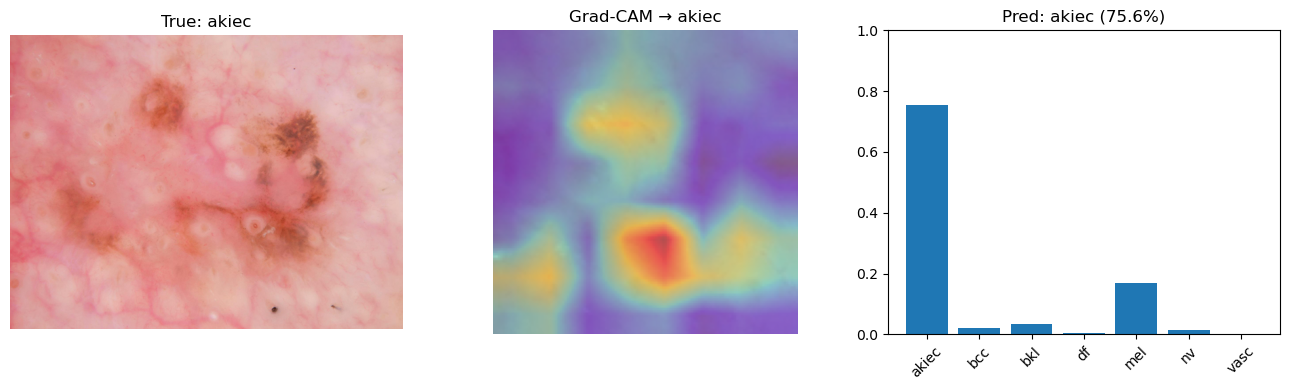

[TEST] True: akiec | Pred: akiec | Confidence: 75.56% | Correct: True


In [31]:
demo_random_inference(split="test", tta=True)

Forward feature shapes: {'stem': (1, 32, 64, 64), 'stage1': (1, 64, 32, 32), 'stage2': (1, 128, 16, 16), 'stage3': (1, 192, 8, 8), 'head': (1, 256, 8, 8)}
Top-3:
  mel: 96.74%
  bcc: 2.68%
  vasc: 0.23%
P(melanoma) = 96.74% | P(carcinoma) = 2.72%


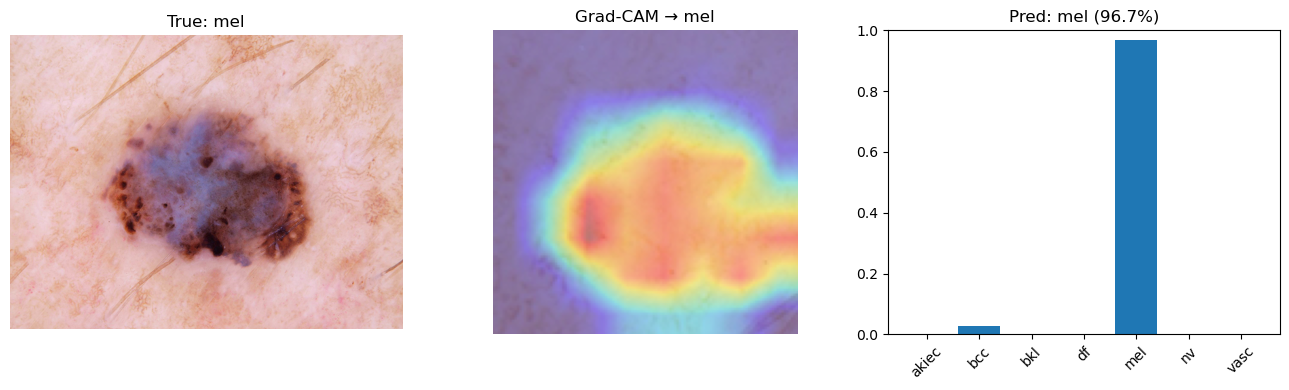

[TEST] True: mel | Pred: mel | Confidence: 96.74% | Correct: True


In [37]:
demo_random_inference(split="test", tta=True)